# DistributedOptimizer


- from megatron.core.optimizer import DistributedOptimizer 是 Megatron-LM（以及基于其核心库 mcore 的框架）中用于大规模分布式训练的核心优化器类。
- <font color='red'>简单来说，它是ZeRO-1（Zero Redundancy Optimizer Stage 1）策略在 Megatron 框架中的具体实现。</font>
- <font color='green'>它的核心目标是打破显存瓶颈，通过将优化器状态（如 Adam 优化器中的动量 Momentum 和方差 Variance）在数据并行（DP）组内的各个 GPU 之间进行切分和存储，从而极大地降低单张显卡的显存占用。</font>

<font color='red'>以下是关于 DistributedOptimizer 的详细原理解析：</font>

## 1. 核心设计理念：显存优化与状态分片
<font color='green'>在传统的分布式数据并行（DDP）训练中，每个 GPU 都会维护一份完整的模型参数、梯度以及优化器状态。</font>当模型参数量达到百亿、千亿级别时，优化器状态（通常是 FP32 格式）会占据绝大部分显存。

DistributedOptimizer 的核心思想是：
- <font color='red'>状态分片（Sharding）</font>：<font color='green'>将优化器状态（以及 FP32 的主参数副本）均匀地切分成 N 份（N 为数据并行度 DP size），每个 GPU 只负责维护和更新其中的一份。</font>
- <font color='red'>按需通信</font>：<font color='green'>在训练过程中，通过高效的集合通信操作，让各个 GPU 交换必要的梯度和参数信息，从而在保持数学等价性的前提下，大幅减少显存冗余。</font>


## 2. 核心数据结构：梯度缓冲区（Grad Buffer）

<font color='red'>DistributedOptimizer 实现的基础是连续的梯度缓冲区（Grad Buffer）。</font>
- 连续内存：它将模型中所有的参数梯度<font color='red'>映射到一块或几块连续的内存区域中，而不是零散地存储在每个 Parameter 对象里。</font>
- 高效管理：<font color='red'>这种设计不仅方便进行内存对齐和填充，还为后续的高效通信（如 Reduce-Scatter 和 All-Gather）提供了极大的便利。</font>

## 3. 完整的工作流程（Step-by-Step）
DistributedOptimizer 的一次参数更新（step）主要包含以下几个关键阶段：
1. 梯度归约与分片（Reduce-Scatter）：
- 在反向传播（Backward）结束后，各个 DP 组内的 GPU 拥有完整的梯度。
- 此时执行 Reduce-Scatter 操作：全局的梯度会被分块，并在各个 GPU 上进行累加求和。最终，每个 GPU 只保留属于自己负责的那一部分梯度分片，其余部分的显存可以被回收。

2. 独立更新（Optimizer Step）：
- <font color='red'>每个 GPU 使用自己持有的 FP32 主参数分片和刚刚得到的梯度分片，独立执行优化器更新（如 Adam 更新）。</font>
- 注意：为了保证数值稳定性，优化器的更新计算必须在 FP32 精度下进行（即使是混合精度训练）。

3. 参数同步（All-Gather）：
- <font color='red'>更新完成后，每个 GPU 只拥有最新的局部参数分片。</font>
- <font color='green'>此时执行 All-Gather 操作：各个 GPU 将自己更新后的参数分片广播给组内其他 GPU，最终所有 GPU 都能拼凑出完整且最新的模型参数，用于下一轮的前向传播。</font>

## 🎬 场景设定
假设我们有一个包含 12个参数 的模型（P0 到 P11），并使用 3张 GPU（Rank 0, Rank 1, Rank 2）进行数据并行训练。
- 每张 GPU 必须拥有一份完整的模型参数副本
- 分片规则：我们将参数和优化器状态平均分成 3 份。
    - Rank 0 负责更新：P0, P1, P2, P3
    - Rank 1 负责更新：P4, P5, P6, P7
    - Rank 2 负责更新：P8, P9, P10, P11
### 1. 梯度归约与分片（Reduce-Scatter）
在反向传播（Backward）刚结束时，由于每个 GPU 处理的数据批次不同，它们各自算出了一份完整的、但互不相同的梯度（我们记为 G0-G11）。
<font color='red'>传统的 DDP 会使用 All-Reduce，让每张卡都得到一份全局平均后的完整梯度。而 DistributedOptimizer 使用的是 Reduce-Scatter：</font>
- Reduce（归约）：它会将所有 GPU 上的梯度进行累加求和（或求平均）。
- Scatter（分片）：<font color='red'>它不会把完整的结果发给所有人，而是“谁负责哪部分参数，就把哪部分的梯度发给谁”。</font>
#### 📌 举例：
- Rank 0：把自己算出的 G0-G3 留下，把 G4-G11 发送给 Rank 1 和 Rank 2。同时，它接收 Rank 1 和 Rank 2 发来的 G0-G3，并在本地完成累加平均。
- Rank 1：留下 G4-G7，接收并累加来自其他卡的 G4-G7。
- Rank 2：留下 G8-G11，接收并累加来自其他卡的 G8-G11。

结果：通信结束后，Rank 0 手里只有 [avg(G0), avg(G1), avg(G2), avg(G3)]，其余的梯度内存被释放。Rank 1 和 Rank 2 同理。

### 2. 独立更新（Optimizer Step）
这一步是纯粹的本地计算，没有任何 GPU 之间的通信。
<font color='red'>因为每个 GPU 现在都持有“自己负责的那部分参数的完整梯度”，并且它们本地也正好存着“自己负责的那部分 FP32 主参数和优化器状态（动量、方差等）”，所以它们可以独立开工了。</font>
#### 📌 举例：
- Rank 0：拿出本地的 FP32 主参数 P0-P3、优化器状态（Adam 的 m 和 v），结合刚刚拿到的 avg(G0-G3)，执行 Adam 更新公式，算出最新的 P0-P3。
- Rank 1：同理，只更新 P4-P7。
- Rank 2：同理，只更新 P8-P11。

结果：此时，整个模型的最新参数其实是分散在三张显卡上的，每张卡只知道局部真理。

### 3. 参数同步（All-Gather）
为了进行下一轮的前向传播（Forward Pass），每张显卡都必须拥有一份完整的、最新的模型参数。这就需要 All-Gather 登场了。
- Gather（收集）：<font color='red'>每个 GPU 将自己刚刚更新好的那部分参数分片，广播发送给组内其他所有 GPU。</font>
- All（全员）：所有 GPU 同时发送并接收，最后把收到的分片在本地拼接起来。

#### 📌 举例：
- Rank 0：把自己更新好的 P0-P3 发给 Rank 1 和 Rank 2。同时接收 Rank 1 发来的 P4-P7，以及 Rank 2 发来的 P8-P11。
拼接：Rank 0 将收到的数据按顺序拼好，得到完整的 [P0, P1, ..., P11]。
- Rank 1 和 Rank 2 也执行完全相同的操作。

<font color='red'>结果：所有 GPU 再次拥有了完全一致的完整模型参数，准备迎接下一个 Batch 的数据。</font>

## 4. 性能优化：通信与计算重叠（Overlap）
为了进一步榨干硬件性能，Megatron 的 DistributedOptimizer 引入了通信与计算重叠的机制：

- <font color='red'>梯度通信重叠（Overlap Grad Reduce）</font>：将 Reduce-Scatter 操作打散，与反向传播（Backward）的计算过程重叠进行。即一部分层的梯度计算完后立刻开始通信，而不需要等待整个模型的反向传播全部结束。
- <font color='red'>参数通信重叠（Overlap Param Gather）</font>：将 All-Gather 操作与前向传播（Forward）的计算过程重叠。在计算当前层时，提前异步获取下一层所需的参数分片。

这种流水线式的重叠设计，能够有效掩盖分布式通信带来的延迟，显著提升大模型训练的吞吐量。

## 总结
- DistributedOptimizer 是大模型训练的基石之一。它通过Grad Buffer、状态分片以及Reduce-Scatter/All-Gather 通信模式，成功解决了超大模型训练时的显存墙问题，并通过通信计算重叠技术保证了极高的训练效率。在 VeRL 等框架中引入它，正是为了能够高效地微调和训练超大规模的强化学习策略模型。

In [2]:
from IPython.display import Image

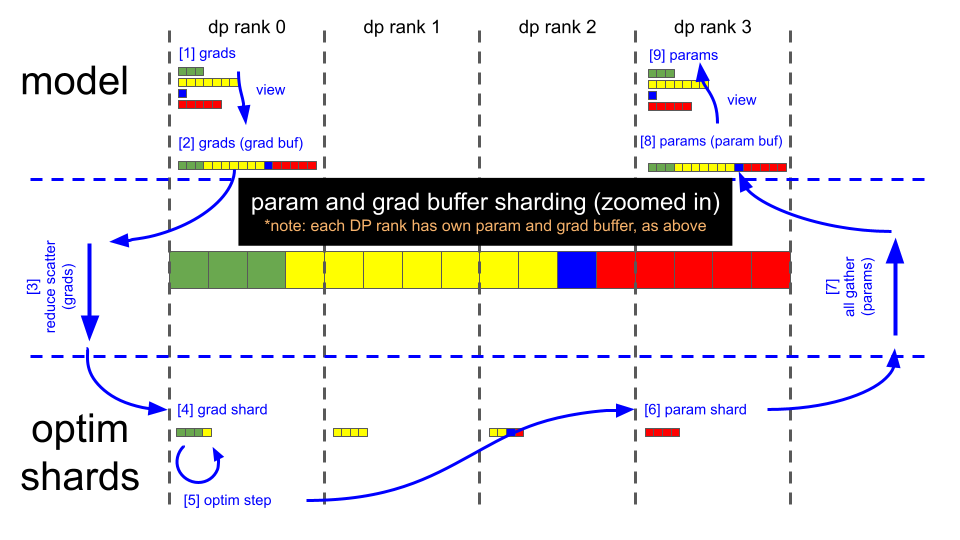

In [3]:
Image(filename='./data_flow.png')

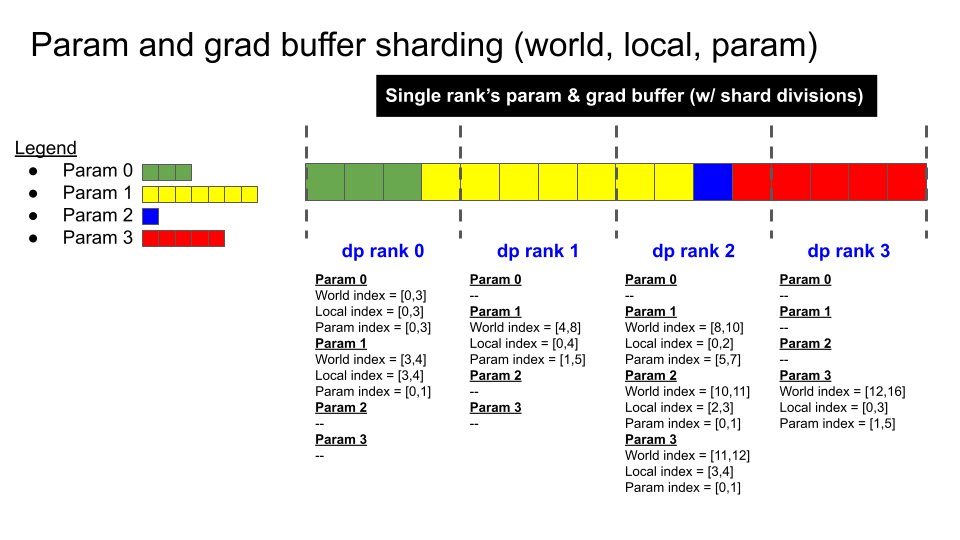

In [4]:
Image(filename='./sharding_scheme.png')

###### 这两张图非常清晰地展示了 Megatron-LM 中 DistributedOptimizer 的核心机制。
- <font color='red'>它解释了模型参数（Params）和梯度（Grads）是如何在物理内存（Buffers）中存储的，以及它们是如何在逻辑上被分片（Sharding）和索引的。</font>

这里有两个核心概念需要区分：物理存储 和 逻辑视图。
- 物理存储：为了计算效率，Megatron 将所有参数和梯度拉平，存储在连续的 Param Buffer 和 Grad Buffer 中。
- 逻辑视图：为了实现 ZeRO-1 显存优化，优化器状态只保存 Buffer 的一部分（Shard）。

以下是结合这两张图的详细步骤解析：

## 第一步：构建连续的缓冲区（图 2 上半部分）
在 Megatron 中，模型不再是一个个独立的 nn.Parameter 对象，而是被“拍平”并拼接成了巨大的连续内存块。
- Param Buffer：存放所有模型参数的 FP32 副本（Main Weights）。
- Grad Buffer：存放所有模型参数的梯度。
- 颜色编码：
    - 绿色：代表 Param 0 的权重/梯度。
    - 黄色：代表 Param 1 的权重/梯度。
    - 蓝色：代表 Param 2。
    - 红色：代表 Param 3。
###### 图 2 的关键点：
- 你可以看到顶部的长条，这就是单张卡上的完整 Buffer。它包含了绿色、黄色、蓝色、红色块。这意味着在计算前向/反向传播时，每张卡都拥有完整的模型参数视图。

## 第二步：数据并行分片（图 2 下半部分 & 图 1 中间）
这是 ZeRO-1 的核心。虽然 Buffer 是完整的，但 Optimizer State（优化器状态） 只负责更新其中的一段。
我们将 DP World Size 设为 4（Rank 0, 1, 2, 3）。长条 Buffer 被切成了 4 份：
- DP Rank 0：负责更新 Buffer 的第 1/4（主要是绿色 Param 0 的一部分）。
- DP Rank 1：负责更新 Buffer 的第 2/4（主要是黄色 Param 1 的一部分）。
- DP Rank 2：负责更新 Buffer 的第 3/4（主要是黄色 Param 1 尾部 + 蓝色 Param 2）。
- DP Rank 3：负责更新 Buffer 的第 4/4（主要是红色 Param 3）。
##### 索引的复杂性（图 2 的文字部分）：
注意看 Rank 1 的配置：
- 它看不到 Param 0（显示为 --）。
- 它看到了 Param 1 的一部分。
- World Index：该参数在整个模型中的绝对位置（例如 Param 1 在 4-8 位置）。
- Local Index：该参数在当前 Rank 的 Shard 中的相对位置（例如在 Rank 1 的 Shard 中，它从 0 开始）。

## 第三步：详细流程解析（结合图 1 的箭头）
图 1 展示了从模型计算到优化器更新的完整数据流向：
1. 模型视图与缓冲区映射（箭头 1 & 8）
- 箭头 1 (Model Grads -> Grad Buf)：反向传播计算出的梯度（分散的张量）被 view 或拷贝到连续的 Grad Buffer 中。
- 箭头 8 (Param Buf -> Model Params)：在更新前，优化器维护的 FP32 参数会被同步回模型的 Param Buffer，进而映射回模型层。
2. 梯度归约与分片（箭头 3：Reduce-Scatter）
- 输入：每张卡上的 Grad Buffer 都是满的（包含绿黄蓝红所有颜色）。
- 操作：执行 Reduce-Scatter。
- 结果：
    - Rank 0 丢弃了黄、蓝、红梯度，只保留并累加了 绿色梯度（它负责的部分）。
    - Rank 1 只保留 黄色梯度。
    - 这就是图 1 中 [4] Grad Shard 的来源。此时显存大幅释放。
3. 独立更新（箭头 5：Optim Step）
- 输入：本地的 [4] Grad Shard 和本地的 [6] Param Shard（以及对应的 Optimizer States 动量等）。
- 操作：执行优化器公式（如 Adam 更新）。
- 结果：仅更新了当前 Rank 负责的那部分参数分片。
4. 参数同步（箭头 7：All-Gather）
- 问题：下一轮迭代的前向传播需要 完整 的参数，但现在参数是分散的。
- 操作：执行 All-Gather。
- 过程：
    - Rank 0 把自己更新好的绿色参数发给 Rank 1, 2, 3。
    - Rank 1 把自己更新好的黄色参数发给 Rank 0, 2, 3。
    - ...
- 结果：所有 Rank 重新拼凑出了完整的 Param Buffer（回到箭头 8 的状态）。

## 总结
这两张图揭示了 Megatron DistributedOptimizer 的精髓：
1. 计算时：通过 Buffer 机制，让每张卡看起来拥有完整的模型，保证计算逻辑不变。
2. 通信时：通过 Reduce-Scatter 把完整的梯度切碎，只留下自己该管的那一份。
3. 更新时：只更新自己那一份（Shard），从而将优化器显存占用降低为原来的 1/DP_Size 。
4. 循环时：通过 All-Gather 把切碎的参数重新拼起来，准备下一次计算。